<a href="https://colab.research.google.com/github/Tecnologico-de-Monterrey-MNA/iayaa-Equipo-42/blob/main/Actividad_Semana_9_Equipo42.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

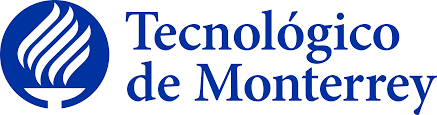

#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Inteligencia Artificial y Aprendizaje Automático**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana 9**
###**Práctica: Bayes ingenuo y vecino más cercano**


**Nombres y matrículas de los integrantes del equipo:**

*  Norma de los Ángeles García López A01228278
*  Ramón Ariel Iván Muñoz Corona A01330566
*  Denisse María Ramírez Colmenero A01561497
*  Ignacio Valdés Reyes  A01793262
*  Rigoberto Vega Escudero. A01793132 

1) Realiza un resumen de máximo 1 cuartilla de dicho artículo.

Con base a la taxonomía de tres tipos de métricas definidas en el artículo (threshold, probabilistic and ranks) analiza los siguientes conjuntos de datos y en cada uno de ellos deberás hacer una propuesta de cuál o cuáles serían las mejores métricas a utilizar en cada caso. Justifica adecuadamente cada propuesta de acuerdo al tipo de problema y tipo de datos. 

En particular haz énfasis en la métricas que hemos estado estudiando en el curso, las cuales de manera
general han sido varias de las principales que usualmente se aplican, o en dado caso algunas de sus
variantes. Asimismo determina se lo consideras un problema de clases o no balanceadas. Lee la
información de cada liga para que contextuelices el “entendimiento del negocio”. 



# **1. Resumen.**
## Una comparación experimental de las medidas de rendimiento para clasificación.
C. Ferri, J. Hernández-Orallo, R. Modroiu

Las medidas de performance dentro de la clasificación son fundamentales en la evaluación de la calidad de los métodos de aprendizaje.

La correcta evaluación de los modelos con un aprendizaje dado es el problema más importante en el reconocimiento de patrones. Podemos tener de un lado una evaluación basada en significados estadísticos o intervalos de confianza, para obtener que un modelo es mejor que otro, pero a la vez queremos tener confianza en estas evaluaciones de cuál es la mejor métrica para evaluar un modelo. Este artículo estará usando 18 métricas diferentes que están clasificadas en 3 familias.

- Métricas basadas en un umbral y una comprensión cualitativa de error: precisión, precisión macro promediada (aritmética y geométrica), medida OF media (puntuación F) y estadística Kappa. Estas medidas se utilizan cuando queremos un modelo que minimice el número de errores.

- Métricas basadas en una comprensión probabilística del error, es decir, midiendo la desviación de la verdadera probabilidad: error absoluto medio, error cuadrático medio (puntaje de Brier), LogLoss (entropía cruzada), dos versiones de la tasa de probabilidad (rango) y dos medidas para calibración. Estas medidas son especialmente útiles cuando queremos evaluar la fiabilidad de los clasificadores, no sólo midiendo cuándo fallan sino si ha seleccionado la clase equivocada con una probabilidad alta o baja.

- Métricas basadas en qué tan bien clasifica el modelo los ejemplos: AUC, que para dos clases es equivalente a la estadística de Mann-Whitney-Wilcoxon, y está estrechamente relacionada con el concepto de separabilidad. Estos son importantes para muchas aplicaciones, como campañas de correo electrónico, gestión de relaciones con clientes (CRM), sistemas de recomendación, detección de fraude, filtrado de spam, etc.

Cada métrica por separado tiene su propia definición, fórmula, etc. Las cuales nos dicen las propiedades y cómo utilizarlas en modelos de Machine Learning. Pero en general se busca tener interés en medidas que sean sensitivas a buena elección del umbral, métricas que cuantifiquen la calidad de los datos y medidas que cuantifiquen la desviación de las probabilidades.

Para evaluar todas estas métricas se usaron 6 modelos de aprendizaje automático como J48, Naive Bayes, Logistic Regression, Multilayer Perceptron, K-Nearest Neighbour y AdaBoost. Para evaluar 30 conjuntos de datos de todos los tipos, balanceados, no balanceados, binarios, multiclase. Una observación general es que todas las correlaciones son positivas y, por lo general, fuertes superiores a 0,5). Las únicas excepciones claras son algunas correlaciones entre LogL y algunas medidas probabilísticas, que a priori podríamos considerar en la misma familia.

También, además se llevan a cabo análisis de sensibilidad a los resultados ya que, a pesar de ver resultados con las correlaciones positivas, podemos introducir ruidos a los modelos para ver como esto altera el comportamiento de los resultados de nuevo. 

Tipos de Ruido:

- Ruido de clasificación errónea: el ruido se aplica a las clases reales
- Ruido de probabilidad: el ruido se aplica a las probabilidades que producen los modelos para cada predicción.
Clasificación de ruido: el ruido se aplica a la clasificación de la predicción del modelo.
- Ruido de proporción de clase: el ruido se aplica a la frecuencia de las clases del conjunto de datos, es decir, variamos la proporción de clases.

Donde se pudo determinar que la precisión y otras medidas cuantitativas son las mejores cuando el ruido está presente en los conjuntos de datos y consecuentemente los modelos evaluados bajo estas métricas serán más robustos. Pero teniendo en cuenta que pueden llegar a ser malos cuando la distorsión se produce durante el entrenamiento. Para estos casos el AUC o medidas basadas en la probabilidad funcionarán mejor.

El análisis anterior muestra que la mayoría de las medidas utilizadas en el aprendizaje automático y el reconocimiento de patrones para evaluar clasificadores realmente miden cosas diferentes, especialmente para problemas multiclase y problemas con distribución de clase desequilibrada, donde las correlaciones son peores. Uno de los resultados más sorprendentes del estudio es que las correlaciones entre métricas dentro de una misma familia no son muy altas, lo que demuestra que con una comprensión probabilística del error es muy diferente usar MSE, LogL o MPR. Es aún más diferente para las medidas de calibración. Con una comprensión cualitativa del error, todavía es diferente usar Acc o MAvG, aunque las correlaciones en este grupo son más altas. El único grupo compacto ocurre cuando queremos clasificar las predicciones, y no es significativamente diferente usar diferentes variantes de AUC.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns
import pandas as pd
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Breast Cancer Wisconsin (Diagnostic) Data Set

In [3]:
mypath = '/content/drive/MyDrive/Colab Notebooks/Inteligencia Artificial/Actividad 10/Breast Cancer/breast-cancer-wisconsin.data'
data_BC = pd.read_csv(mypath, sep=",", header=None)
data_BC.columns = ['id','ct','cell_size','cell_shape','ma','e','bn','bch','nn','mitoses','class']
# data_BC.columns = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11']
data_BC.head()

,id,ct,cell_size,cell_shape,ma,e,bn,bch,nn,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [4]:
data_BC.isnull().any()

id            False
ct            False
cell_size     False
cell_shape    False
ma            False
e             False
bn            False
bch           False
nn            False
mitoses       False
class         False
dtype: bool

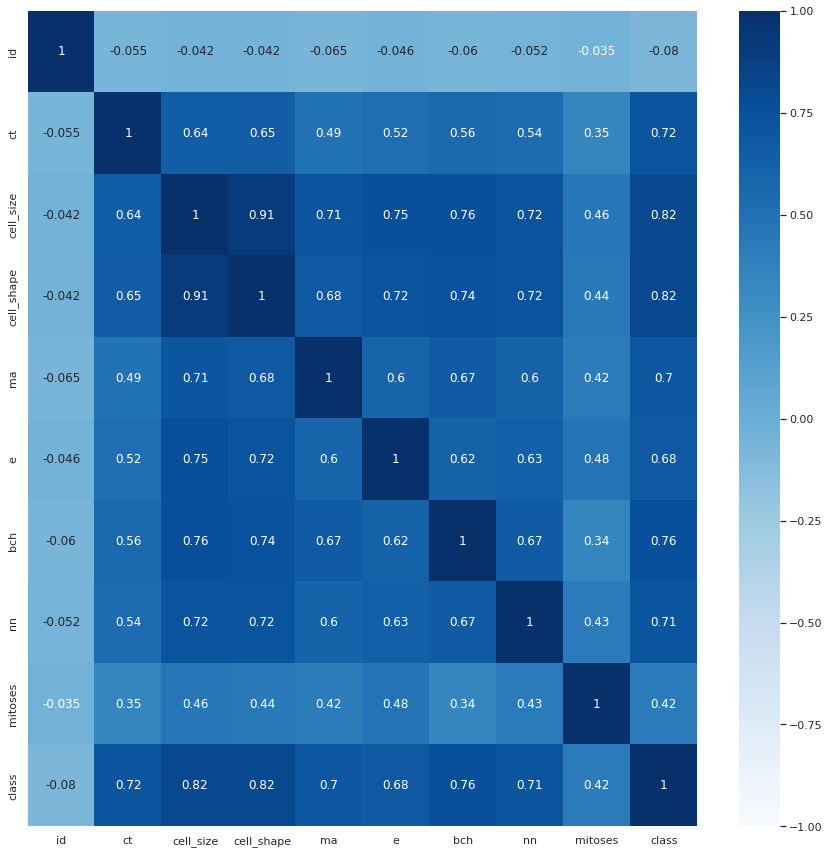

In [5]:
data_BC.corr()
corrs = data_BC.corr()
sns.set(rc = {'figure.figsize':(15,15)})
sns.heatmap(corrs, vmin = -1, vmax = 1, cmap = "Blues", annot= True)

In [6]:
data_BC.describe()

,id,ct,cell_size,cell_shape,ma,e,bch,nn,mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


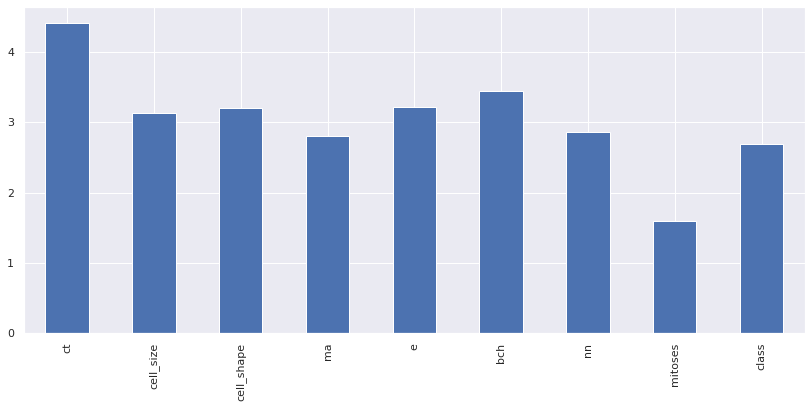

In [7]:
from seaborn.rcmod import palettes
x = data_BC.drop('id', axis='columns')
data_mean = x.describe().loc['mean']
data_mean.plot(kind='bar', figsize=(14,6))

In [8]:
data_BC.dtypes

id             int64
ct             int64
cell_size      int64
cell_shape     int64
ma             int64
e              int64
bn            object
bch            int64
nn             int64
mitoses        int64
class          int64
dtype: object

##Técnicas de Balanceo: 

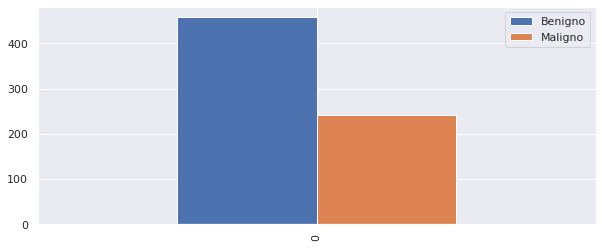

In [9]:
tumorB = data_BC[data_BC['class'] == 2]
tumorM = data_BC[data_BC['class'] == 4]
dataclass = {'Benigno': [tumorB.shape[0]], 'Maligno': [tumorM.shape[0]]}
dfBM = pd.DataFrame(data=dataclass)
dfBM.plot(kind='bar', figsize=(10,4))

##Falsos Positivos y Falsos Negativos: 

Como podemos ver en este análisis del dataset y en la descripción del mismo, hay un desbalanceo evidente de las clases, tan solo el 34.5% de las muestras pertenecen a la clase positiva, mientras que la clase mayoritaria (negativa) tiene 65.5%, lo cual es casi el doble de la minoritaria. 

Clase minoritaria = Maligno = Clase positiva. 

Clase mayoritaria = Beningno = Clase negativa. 

En un conjunto de desbalanceo de clases como este, el modelo será muy bueno prediciendo la clase mayoritaria, (en este caso los pacientes que tienen tumor benigno), pero muy malo para predecir la clase minoritaria, ya que el modelo se limitará a responder casi siempre que el paciente pertenece a clase B, dando resultado a un gran numero de falsos negativos. 

Una buena opción para balancear este conjunto de datos sería sobremuestrando la clase minoritaria usando la técnica 'RandomOverSampler' de la librería Imbalance-learn y usando su parámetro 'sampling_strategy', la clase minoritaria podría aumentar su número de muestras a la cantidad que se desee, pudiendo así balancear su conjunto de datos de forma en que las dos clases queden lo más cercano a un 50% cada una. 

Para este conjunto de datos submuestrear la clase mayoritaria no sería tan buena opción ya que al solo tener 699 muestras, estaríamos reduciendo aún más ese número, y mientras menos muestras tengamos, peor será el desempeño del modelo. 

##Métricas de Desempeño:

Al ser un conjunto de datos desbalanceado, con una salida binaria (dos clases), podemos seleccionar las siguientes métricas que mejor miden el desempeño de este dataset:

1. Dado el análisis anterior podríamos usar **F2-Score** cuando el equipo de trabajo decida que es más importante reducir la cantidad de pacientes que tienen cáncer y que no son clasificados como tal, es decir cuando falsos negativos son más importantes, lo cuál podríamos decir que ocurre en la mayoría de los casos, mayormente en países desarrollados. Está métrica es del tipo Umbral (Threshold) y resume el rendimiento predictivo del modelo combinando las métricas de **precisión y recall** pero dando un poco más de peso al recall, el cual permite indicar la proporción de muestras clasificadas correctamente. 
Además haríamos uso de la Curva PR. Esta métrica es del tipo Clasificación (Ranking) y es especial para clases no balanceadas, donde la positiva es más importante. En resumen, la curva PR, la cuál nos permite ver a partir de qué recall tenemos una degradación de la precisión y viceversa.

2. En caso contrario, cuando el equipo de trabajo decida que el esfuerzo humano y el costo económico toma mayor importancia (caso que probablemente ocurriría si hablaramos de un país subdesarrollado) se debería usar la métrica **F1/2 - Score** el cual es igual que la F2-Score pero tomando más peso la precisión (tratando de reducir los falsos positivos). También pertenece al tipo Umbral (Threshold). 

# 3. South German Credit Data Set

In [10]:
mypath = '/content/drive/MyDrive/Colab Notebooks/Inteligencia Artificial/Actividad 10/SouthGermanCredit/SouthGermanCredit.asc'
data_SGC = pd.read_csv(mypath, sep=" ")
data_SGC.columns = ['status','duration','credit_history','purpose','amount','savings','employment_duration',
                'installment_rate','personal_status_sex','other_debtors','present_residence','property','age','other_installment_plans',
                'housing','number_credits','job','people_liable','telephone','foreign_worker','credit_risk']
data_SGC.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


Asi se dividen a las columnas en categoricas, numericas, ordinales y binarios

In [11]:
#Categorical Columns:
cat_cols =  ['status', 'credit_history', 'purpose', 'savings', 'personal_status_sex', 'other_debtors', 'other_installment_plans', 'housing']
#Numerical Columns:
num_cols =  ['duration', 'amount', 'age']
#Ordinal Columns:
ord_cols =  ['employment_duration', 'installment_rate', 'present_residence', 'property', 'number_credits', 'job']
#Binary Columns:
bin_cols =  ['people_liable', 'telephone', 'foreign_worker']

num_na = ord_cols + num_cols
cat_na = cat_cols + bin_cols

Vamos a revisar primero las variables categoricas y la variable de salida

In [12]:
for col in cat_na:
    print("===== " + col + " =====" )
    print(data_SGC[col].value_counts())
    
print("===== Credit Risk =====" )
print(data_SGC["credit_risk"].value_counts())  

===== status =====
4    394
1    274
2    269
3     63
Name: status, dtype: int64
===== credit_history =====
2    530
4    293
3     88
1     49
0     40
Name: credit_history, dtype: int64
===== purpose =====
3     280
0     234
2     181
1     103
9      97
6      50
5      22
10     12
4      12
8       9
Name: purpose, dtype: int64
===== savings =====
1    603
5    183
2    103
3     63
4     48
Name: savings, dtype: int64
===== personal_status_sex =====
3    548
2    310
4     92
1     50
Name: personal_status_sex, dtype: int64
===== other_debtors =====
1    907
3     52
2     41
Name: other_debtors, dtype: int64
===== other_installment_plans =====
3    814
1    139
2     47
Name: other_installment_plans, dtype: int64
===== housing =====
2    714
1    179
3    107
Name: housing, dtype: int64
===== people_liable =====
2    845
1    155
Name: people_liable, dtype: int64
===== telephone =====
1    596
2    404
Name: telephone, dtype: int64
===== foreign_worker =====
2    963
1     37


## Remarks del Dataset

Haciendo un análisis de los datos, podemos denotar lo siguiente:
1.	Es una base de datos cuyo output es un clasificador binario donde nos indica si el contrato crediticio fue cumplido con éxito o sin éxito (1 y 0, respectivamente)
2.	Del balance entre clases, podemos ver que hay un mayor numero de casos positivos, que de casos negativos. Es algo que tendremos que tomar en cuenta para el entrenamiento de los modelos y para las métricas que vamos a utilizar
3.	Por la naturaleza de los datos, donde queremos conocer si este cliente presenta un riesgo para la empresa, podemos usar 2 tipos de métricas: 
    
        a.	Basado en el threshold, dado que nosotros queremos minimizar el numero de errores en las predicciones. La razón es que, si tenemos un alto nivel de errores, esto puede llegar a representar riesgo de perdidas de dinero para la empresa. Esto debido a que una mala clasificación puede significar que se les aprueben créditos a clientes riesgosos. 
    
        b.	Basado en un entendimiento probabilístico del error. La razón de esto es que podemos entender la probabilidad de que se haya clasificado correctamente e identificar con que probabilidad un cliente es riesgoso o no. 

Con base en esto, proponemos las siguientes métricas:
-	Dado que tenemos un desbalance de clases, tenemos que ser cuidadosos en que métricas utilizar. Usaremos F1-Score por un sencillo motivo, esta métrica nos brinda un análisis combinado entre precisión y recall. ¿Porque es importante esto? A diferencia del accuracy que nos da una ratio entre los asignados correctamente y todos los asignados, precisión y recall nos da una ratio entre el número de cada clase vs los elementos que pertenecen a esa clase. Esto nos permite que podamos medir la asignación correcta tanto de la clase mayoritaria, como de la minoritaria. 
-	Usaremos como segunda metrica al Mean Squared Error o en este caso the Brier Score. Esta va a funcionar como una cost function, la cual usaremos para saber que tan precisa es nuestra predicción y que tan bien calibrado esta nuestro modelo para predecir las probabilidades de cada clase. 


# 4.  Telco customer churn: IBM dataset: 


## Contexto

**Telco** es una compañía de telecomunicaciones ficticia que brindó servicios telefónicos y de Internet a personas de California. Los siguientes datos muestran la rotación de clientes, indica qué clientes se han ido, cuáles se han quedado o se han inscrito en su servicio. También, se incluyen varios datos demográficos importantes sobre cada cliente, así como un índice de rotación y un índice de valor del tiempo de vida del cliente.

### Descripción

1.   **CustomerID:** identificación única que identifica a cada cliente.
2.   **Count:** valor que se utiliza en los informes para resumir el número de clientes en un conjunto filtrado.
3.   **Country:** país de residencia del cliente.
4.   **State:** estado de residencia del cliente.
5.   **City:** ciudad de residencia del cliente.
6.   **Zip Code:** código postal de residencia del cliente.
7.   **Lat Long:** latitud y longitud combinadas de la residencia del cliente.
8.   **Latitude:** latitud de la residencia principal del cliente.
9.   **Longitude**: La longitud de residencia del cliente.
10.   **Gender:** género del cliente: Masculino, Femenino
11.   **Senior Citizen:** indica si el cliente tiene 65 años o más: Sí, No
12.   **Partner:** indica si el cliente tiene socio: Si, No
13.   **Dependents:** indica si el cliente vive con algún dependiente: Sí, No. Los dependientes pueden ser hijos, padres, abuelos, etc.
14.   **Tenure Months:** indica la cantidad total de meses que el cliente ha estado con la empresa al final del trimestre especificado anteriormente.
15.   **Phone Service:** indica si el cliente contrata el servicio de telefonía residencial con la empresa: Si, No
16.   **Multiple Lines:** indica si el cliente contrata líneas telefónicas múltiples con la empresa: Si, No
17.   **Internet Service:** indica si el cliente contrata el servicio de Internet con la empresa: No, ADSL, Fibra Óptica, Cable.
18.   **Online Security:** indica si el cliente se suscribe a un servicio adicional de seguridad online proporcionado por la empresa: Si, No
19.   **Online Backup:** indica si el cliente se suscribe a un servicio adicional de respaldo en línea brindado por la empresa: Si, No
20.   **Device Protection:** indica si el cliente se suscribe a un plan adicional de protección de dispositivos para su equipo de Internet provisto por la empresa: Si, No
21.   **Tech Support:** indica si el cliente se suscribe a un plan de soporte técnico adicional de la empresa con tiempos de espera reducidos: Si, No
22.   **Streaming TV:** indica si el cliente utiliza su servicio de Internet para transmitir programación de televisión de un tercero proveedor: Sí, No. La empresa no cobra una tarifa adicional por este servicio.
23.   **Streaming Movies:** indica si el cliente utiliza su servicio de Internet para transmitir películas de un proveedor externo: Sí, No. La empresa no cobra una tarifa adicional por este servicio.
24.   **Contract:** indica el tipo de contrato actual del cliente: Mes a Mes, Un Año, Dos Años.
25.   **Paperless Billing:** indica si el cliente ha elegido la facturación sin papel: Sí, No
26.  **Payment Method:** indica cómo el cliente paga su factura: Retiro bancario, Tarjeta de crédito, Cheque enviado por correo
27.   **Monthly Charge:** indica el cargo mensual total actual del cliente por todos sus servicios de la empresa.
28.   **Total Charges:** indica los cargos totales del cliente, calculados al final del trimestre especificado anteriormente.
29.   **Churn Label:** Sí = indica si el cliente dejó la empresa este trimestre. No = el cliente se quedó con la empresa. Directamente relacionado con Churn Value.
30.   **Churn Value:** 1 = indica si el cliente dejó la empresa este trimestre. 0 = el cliente se quedó con la empresa. Directamente relacionado con Churn Label.
31.   **Churn Score:** valor de 0 a 100 que se calcula utilizando la herramienta predictiva *IBM SPSS Modeler*. El modelo incorpora múltiples factores que se sabe que causan abandono. Cuanto más alto sea el puntaje, más probable es que el cliente abandone.
32.   **CLTV:** valor del tiempo de vida del cliente. Un CLTV pronosticado se calcula utilizando fórmulas corporativas y datos existentes. Cuanto mayor sea el valor, más valioso será el cliente. Los clientes de alto valor deben ser monitoreados por abandono.
33.   **Churn Reason:** motivo específico de un cliente para abandonar la empresa. Directamente relacionado con la categoría Churn.

In [13]:
mypath = '/content/drive/MyDrive/Colab Notebooks/Inteligencia Artificial/Actividad 10/Telco customer churn IBM dataset/Telco_customer_churn.xlsx'
data_TCC = pd.read_excel(mypath)
data_TCC.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [14]:
data_TCC.shape

(7043, 33)

In [15]:
data_TCC.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [16]:
data_TCC.isnull().any()

CustomerID           False
Count                False
Country              False
State                False
City                 False
Zip Code             False
Lat Long             False
Latitude             False
Longitude            False
Gender               False
Senior Citizen       False
Partner              False
Dependents           False
Tenure Months        False
Phone Service        False
Multiple Lines       False
Internet Service     False
Online Security      False
Online Backup        False
Device Protection    False
Tech Support         False
Streaming TV         False
Streaming Movies     False
Contract             False
Paperless Billing    False
Payment Method       False
Monthly Charges      False
Total Charges        False
Churn Label          False
Churn Value          False
Churn Score          False
CLTV                 False
Churn Reason          True
dtype: bool

## Tipos de datos

Los datos están relacionados según las siguiente categorías:
-   Demografía
-   Ubicación
-   Población
-   Servicios
-   Estado

In [17]:
data_TCC.describe

<bound method NDFrame.describe of       CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long 



```
# Tiene formato de código
```

### AUC

A continuación, tomando en cuenta las 3 familias que aparecen en el articulo, seleccionamos la ideal pensando en un modelo que permita **predecir los clientes que abandonarán la compañía, además de indicar en cuál de los casos es importante realizar una contra-oferta según el valor del tiempo de vida del cliente**; con el propósito de ofrecer recomendaciones estratégicas de la problemática del negocio.

Priorizamos la familia de **métricas basadas en qué tan bien clasifica el modelo los ejemplos**, para garantizar que los clientes que abandonarán sean filtrados de manera correcta (alto valor) y gestionarlos, a fin de no poner en peligro la relación con estos.

De manera particular, la métrica **Area Under the ROC Curve (AUC)** por su buen manejo de las siguientes 3 características relevantes sobre el problema:

1. **Precisión:**
  -   AUC recomienda modelos que optimizan tanto las tasas de verdaderos positivos como las de falsos positivos que están significativamente por encima de la probabilidad aleatoria, lo que no se garantiza con precisión como métrica de evaluación. Esto es importante ya que necesitamos confianza en nuestras predicciones de clase positivas cuando tomamos medidas de retención.

  -   Si usamos AUC para seleccionar modelos con un conjunto de datos de validación, obtenemos mejores resultados en precisión que cuando empleamos precisión para seleccionar los modelos.

2. **Multi-clase:**
  -   AUC es una herramienta útil para evaluar la calidad de la separación de clases para los clasificadores blandos. En la configuración multi-clase, podemos visualizar el rendimiento de los modelos multi-clase de acuerdo a sus curvas one-vs-all precision-recall.

3. **Variables categóricas:**
  -   AUC of each class against each other, using the uniform class distribution: (AU1U) representa la aproximación de AUC en el caso de clasificadores multidimensionales, calculando el AUC de *c(c-1)* clasificadores binarios (todas las posibles combinaciones por pares) y considerando la distribución uniforme de las clases.

  -   El AUC de un clasificador binario es equivalente a la probabilidad de que clasifique una instancia positiva elegida al azar, más alta que una instancia negativa elegida al azar.

## Consideraciones: datos no balanceados

Según el ejercicio "Customers Churn Prediction: ROC AUC" de Naomi G., el modelo con los datos balanceados, no resultó con la mejor mesura entre ROC AUC, TP y FP rates; entonces, con los datos no balanceados, hay mayor equilibrio entre ROC AUC y FN rate. Esto significa que el modelo difícilmente falla en predecir qué clientes es probable que abandonen.

# 5. Qualitative_Bankruptcy Data Set

Contexto
Numerosos estudios sobre la predicción de quiebras han aplicado ampliamente técnicas de minería de datos para descubrir automáticamente el conocimiento útil de las bases de datos financieras, mientras que pocos estudios han propuesto enfoques cualitativos de minería de datos capaces de obtener y representar el conocimiento de resolución de problemas de los expertos a partir de las decisiones cualitativas de los expertos. En un proceso real de evaluación de riesgos, el descubrimiento del conocimiento de predicción de quiebra de los expertos todavía se considera una tarea importante porque las predicciones de los expertos dependen de su subjetividad. Este artículo propone un método de minería de datos basado en algoritmos genéticos para descubrir reglas de decisión de quiebra a partir de decisiones cualitativas de expertos. Los resultados del experimento muestran que el algoritmo genético genera reglas que tienen mayor precisión y mayor cobertura que los métodos de aprendizaje inductivo y las redes neuronales. También indican que se logra un acuerdo considerable entre el método GA y el conocimiento de resolución de problemas de los expertos. Esto significa que el método propuesto es una herramienta adecuada para obtener y representar las reglas de decisión de los expertos y, por lo tanto, proporciona apoyos de decisión efectivos para resolver problemas de predicción de quiebra.

In [18]:
mypath = '/content/drive/MyDrive/Colab Notebooks/Inteligencia Artificial/Actividad 10/Qualitative_Bankruptcy Data Set/Qualitative_Bankruptcy.data.txt'
data_QBK = pd.read_csv(mypath, sep=",", header=None)
data_QBK.columns = ['Industrial Risk','Management Risk','Financial Flexibility','Credibility','Competitiveness','Operating Risk','Class']
data_QBK.head()

,Industrial Risk,Management Risk,Financial Flexibility,Credibility,Competitiveness,Operating Risk,Class
0,P,P,A,A,A,P,NB
1,N,N,A,A,A,N,NB
2,A,A,A,A,A,A,NB
3,P,P,P,P,P,P,NB
4,N,N,P,P,P,N,NB


In [20]:
data_QBK.describe

<bound method NDFrame.describe of     Industrial Risk Management Risk Financial Flexibility Credibility  \
0                 P               P                     A           A   
1                 N               N                     A           A   
2                 A               A                     A           A   
3                 P               P                     P           P   
4                 N               N                     P           P   
..              ...             ...                   ...         ...   
245               N               N                     A           N   
246               P               N                     N           N   
247               A               N                     N           N   
248               N               N                     N           N   
249               P               N                     N           N   

    Competitiveness Operating Risk Class  
0                 A              P    NB  
1  

## **Tipo de Datos**

**Información de atributos: (P = Positivo, A-Promedio, N-negativo, B-Quiebra, NB-No Quiebra)**

     1. Riesgo Industrial: {P,A,N}
     2. Riesgo de Gestión: {P,A,N}
     3. Flexibilidad financiera: {P,A,N}
     4. Credibilidad: {P,A,N}
     5. Competitividad: {P,A,N}
     6. Riesgo operativo: {P,A,N}
     7. Clase: {B, NB}

 *Riesgos Internos:*

1.   Riesgo de la industria (IR) :
     

  *   Políticas gubernamentales y acuerdos internacionales,
  *   Ciclicidad 
  *   Grado de competencia,
  *   El precio y la estabilidad de la oferta del mercado,
  *   El tamaño y el crecimiento de la demanda del mercado,
  *   La sensibilidad a los cambios en los factores macroeconómicos
  *   Poder competitivo nacional e internacional.
  *   Ciclo de vida del producto.




2.   Riesgo de gestión (MR) :
  *   Capacidad y competencia de la dirección
  *   Estabilidad de la gestión
  *   La relación entre dirección/propietario
  *   Administración de recursos humanos
  *   Proceso de crecimiento/rendimiento empresarial
  *   Planificación comercial a corto y largo plazo
  *   realización y viabilidad


3.   Flexibilidad financiera (FF):
  *   Financiamiento directo
  *   Financiamiento indirecto
  *   Otra financiación


4.   Credibilidad (CR):
  *   Historial de crédito
  *   Confiabilidad de la información
  *   La relación con las entidades financieras


5.   Competitividad (CO) :
  *   Posición de mercado
  *   El nivel de las capacidades básicas
  *   Estrategia diferenciada


6.   Riesgo Operativo (OP):
  *   La estabilidad y diversidad de las adquisiciones
  *   La estabilidad de la transacción
  *   La eficiencia de la producción
  *   Las perspectivas de demanda de productos y servicios
  *   Diversificación de ventas
  *   Precio de venta y condición de liquidación
  *   Cobro de A/R
  *   Eficacia de la red de venta

In [21]:
data_QBK.shape

(250, 7)

In [23]:
data_QBK.isnull().sum()

Industrial Risk          0
Management Risk          0
Financial Flexibility    0
Credibility              0
Competitiveness          0
Operating Risk           0
Class                    0
dtype: int64

In [25]:
data_QBK.isnull().any()

Industrial Risk          False
Management Risk          False
Financial Flexibility    False
Credibility              False
Competitiveness          False
Operating Risk           False
Class                    False
dtype: bool

## **Consideraciones para FN y FP**

El área bajo la curva ROC, o simplemente AUC, resume la relación entre
la tasa de verdaderos y falsos positivos de un clasificador binario, para diferentes umbrales de decisión.
Varios autores han demostrado que AUC es más preferible para la evaluación del clasificador que la precisión total, lo que la convierte en una de las métricas más populares para datos estáticos desequilibrados.
Sin embargo, para calcular el AUC, es necesario ordenar un conjunto de datos dado e iterar a través de cada uno.
ejemplo. Esto significa que AUC no se puede calcular directamente en grandes flujos de datos, ya que esto requeriría escanear todo el flujo después de cada ejemplo. Por eso, el uso del AUC para flujos de datos se ha limitado solo a estimaciones en conjuntos de retención periódicos o flujos completos, lo que lo hace potencialmente sesgado o computacionalmente inviable

## **Decide y justifica la métrica a utilizar**

### Escenarios interesantes

-   ¿Cuántas calificaciones negativas en los factores, tuvieron en promedio las empresas que se fueron  a la bancarota?
-   ¿Cuál es el factor con mayor peso que lleva a la bancarota a  las empresas?

El objetivo de de estas métricas es identificar el factor con mayor peso que por ende tiene influencia en que las empresas lleguen a bancarota

#Conclusión.

En conclusión, podemos ver los distintos afronte que le dimos a las bases de datos, dando no solo una gran diversidad de análisis, sino también de profundidad y riqueza a nuestra entrega. Buscamos primeramente abordar las problemáticas en base a complejidad y reto que pueda presentar cada tipo y creemos haber logrado el objetivo. Y sobre todo que el logramos afianzar mas el uso de las distintas métricas de rendimiento de los modelos de clasificación, como usarla cuando afrontamos clases balanceadas e imbalanceadas. Un reto, pero tuvimos buenas lecciones que podemos seguir aplicando a la hora de tomar la decisión de como evaluar nuestros modelos.

#Referencias.

- C. Ferri, J. Hernández-Orallo, R. Modroiu, An experimental comparison of performance measures for classification, Pattern Recognition Letters, Volume 30, Issue 1, 2009, Pages 27-38.

- William H. Wolberg and O.L. Mangasarian: "Multisurface method of pattern separation for medical diagnosis applied to breast cytology", Proceedings of the National Academy of Sciences, U.S.A., Volume 87, December 1990, pp 9193-9196.

- TY  - BOOK
AU  - Borges, Lucas
PY  - 2015/10/14
SP  - 
T1  - Analysis of the Wisconsin Breast Cancer Dataset and Machine Learning for Breast Cancer Detection
ER  - 

- Zhang, Y. (2019, 30 octubre). Deep Learning in Wisconsin Breast Cancer Diagnosis: A deep learning approach for healthcare. Towards Data Science. https://towardsdatascience.com/deep-learning-in-winonsin-breast-cancer-diagnosis-6bab13838abd

- Cáncer de mama. (s. f.). OPS/OMS | Organización Panamericana de la Salud. https://www.paho.org/es/temas/cancer-mama

- D. Brzezinski, J. Stefanowski Prequential AUC: properties of the area under the ROC curve for data streams with concept drift. Knowl Inf Syst 52, 531–562 (2017). https://doi.org/10.1007/s10115-017-1022-8


-   G., N. (2022, January). Customers Churn Prediction: ROC AUC. Kaggle. https://www.kaggle.com/code/nomssg/customers-churn-prediction-roc-auc/notebook

- J. Jaramillo-Garza, J. Isaac-García. (2012) Modelo probabilístico de quiebra para pequeñas y medianas empresas mexicanas. Una herramienta para la toma de decisiones. https://www.eumed.net/cursecon/ecolat/mx/2012/pequenas-medianas-empresas-mexicanas.pdf

-   Performance Measures for Multi-Class Problems. (2018, December 4). Data Science Blog: Understand. Implement. Succed. https://www.datascienceblog.net/post/machine-learning/performance-measures-multi-class-problems/

-   Telco customer churn (11.1.3+). (2019, July 11). Higher Logic, LLC. https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113

-   Telco customer churn: IBM dataset. (2020, December 7). Kaggle. https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

-   Trevisan, V. (2022, February 12). Multiclass classification evaluation with ROC Curves and ROC AUC. Towards Data Science. https://towardsdatascience.com/multiclass-classification-evaluation-with-roc-curves-and-roc-auc-294fd4617e3a

-   Utterback, C. (2021, April 26). Predict Customer Churn With Precision. Towards Data Science. https://towardsdatascience.com/predict-customer-churn-with-precision-56932ae0e5e3